# 01 · Data Foundations

**Workshop:** AI for Actuaries — From Foundations to AI Agents
**Session / Part:** S1.P2 · Tools and Data
**Slides covered:** S1.P2.10 – S1.P2.15
**Author:** Dr Rohan Yashraj Gupta (FIA, FIAI), with Satya Sai Mudigonda and Sai Krishna Vadali
**Workshop date:** 15 May 2026 · Hilton near Airport, Mumbai
**License:** CC BY-NC 4.0 — for educational use within the IFoA workshop and follow-up case study

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/{org}/{repo}/blob/main/notebooks/01_data_foundations.ipynb)

## What this notebook does
Loads three hypothetical ABC Insurer datasets — Motor, Health, Life — and runs the inspection drills you saw on slides. Computes an exposure-weighted frequency curve for ABC Motor, glances at the Health and Life schemas, and finishes with a three-minute exercise that asks you to find the leakage column.

## Prerequisites
- Google account (for Colab).
- No local install required.

## How to run
Top menu → **Runtime → Run all**. The notebook runs end-to-end on a fresh Colab CPU runtime with no manual steps.

In [1]:
# === Standard imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Notebook-specific imports below
# -------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

## About the data URLs

The three datasets are hosted in the workshop's public GitHub repository at:

```
https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_motor_2024.csv
https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_health_2024.csv
https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_life_term_cohort.csv
```

> **Pre-workshop action — Rohan:** Replace `{org}` and `{repo}` in the URL constants below with the actual GitHub organisation and repository names before workshop day. Until then, the next cell defines an inline-generation fallback so the notebook runs end-to-end today.

The fallback uses `SEED = 42` (NumPy global, set in the imports cell) and is calibrated to the realised figures in `00_personas_and_datasets.md` §7. Once the URLs are live, the inline fallback never fires and every learner downloads the same byte-identical CSVs.

In [2]:
# Public data URLs — single source of truth (replace {org}/{repo} before workshop day).
MOTOR_URL  = "https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_motor_2024.csv"
HEALTH_URL = "https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_health_2024.csv"
LIFE_URL   = "https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_life_term_cohort.csv"


# ---- Inline-generation fallback (only used if the URL is not yet live) ---
# Calibrated to the realised figures in 00_personas_and_datasets.md §7.

def _generate_motor(n: int = 5_000) -> pd.DataFrame:
    """ABC Motor 2024 — 5,000 private car comprehensive policies.

    Inline-fallback seed (350) is tuned so the realised band frequencies in
    Section 2 match the slide-11 chart (~6.2%, 7.5%, 9.4%, 12.1%) to ±0.2pp.
    The canonical CSV in 00_generate_datasets.ipynb uses SEED=42.
    """
    rng = np.random.default_rng(350)
    # Right-skewed age distribution: geometric with mean ~4.7 (personas §7 target)
    age = (rng.geometric(p=0.175, size=n) - 1).clip(0, 20)
    df = pd.DataFrame({
        "policy_id":         [f"ABC-MOT-{i:06d}" for i in range(n)],
        "vehicle_age_years": age,
        "vehicle_make":      rng.choice(
            ["Maruti","Hyundai","Tata","Mahindra","Honda","Toyota","Kia","Other"],
            n, p=[.32,.18,.14,.10,.08,.07,.06,.05]),
        "vehicle_segment":   rng.choice(["Hatchback","Sedan","SUV","MUV"], n, p=[.45,.20,.25,.10]),
        "cubic_capacity":    rng.integers(800, 3_501, n),
        "idv_inr":           rng.integers(200_000, 5_000_001, n),
        "ncb_pct":           rng.choice([0,20,25,35,45,50], n, p=[.30,.20,.15,.15,.10,.10]),
        "policyholder_age":  rng.integers(18, 81, n),
        "policyholder_gender": rng.choice(["M","F","X"], n, p=[.78,.21,.01]),
        "region":            rng.choice(["Tier1","Tier2","Tier3"], n, p=[.45,.35,.20]),
        "prior_claims_3y":   rng.choice([0,1,2,3,4,5], n, p=[.65,.20,.08,.04,.02,.01]),
    })
    # Inception spread across 2024; exposure earned to 31-Dec-2024
    df["inception_date"] = pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 365, n), "D")
    df["expiry_date"]    = df["inception_date"] + pd.Timedelta(days=365)
    obs_end              = pd.to_datetime("2024-12-31")
    df["exposure_years"] = (
        (np.minimum(df["expiry_date"], obs_end) - df["inception_date"]).dt.days.clip(lower=0) / 365
    ).round(4)
    # Frequency model — tuned to hit the slide-11 chart targets across age bands
    # (~6.2%, 7.5%, 9.4%, 12.1% across 0–2, 3–5, 6–10, 11–20).
    # Small NCB and region effects so the honest model in Section 5 can beat
    # 0.5 AUC after the leakage column is removed.
    annual_freq = (
        0.058
        + 0.0041 * df["vehicle_age_years"]
        - 0.0005 * df["ncb_pct"]
        + 0.012 * (df["region"] == "Tier1").astype(int)
    ).clip(lower=0.04)
    lam         = annual_freq * df["exposure_years"]
    df["claim_count"]      = rng.poisson(lam)
    severity               = np.where(df["claim_count"] > 0,
                                       rng.gamma(2.0, 19_000, n).round(0), 0.0)
    df["claim_amount_inr"] = (severity * df["claim_count"]).round(0)
    df["fraud_flag"]       = ((df["claim_count"] > 0) & (rng.random(n) < 0.02)).astype(int)
    return df[[
        "policy_id","inception_date","expiry_date","exposure_years",
        "vehicle_age_years","vehicle_make","vehicle_segment","cubic_capacity",
        "idv_inr","ncb_pct","policyholder_age","policyholder_gender","region",
        "prior_claims_3y","claim_count","claim_amount_inr","fraud_flag",
    ]]


def _generate_health(n_policies: int = 3_200) -> pd.DataFrame:
    """ABC Health 2024 — 3,200 policies, ~7,700 covered lives."""
    rng = np.random.default_rng(SEED + 1)
    rows = []
    for i in range(n_policies):
        n_members = rng.choice([1, 2, 3, 4], p=[0.40, 0.30, 0.20, 0.10])
        rels = (["Self"] +
                rng.choice(["Spouse","Son","Daughter","Parent"], n_members - 1).tolist())                 if n_members > 1 else ["Self"]
        product = rng.choice(["Bronze","Silver","Gold"], p=[.40,.40,.20])
        sum_ins = rng.choice([300_000, 500_000, 1_000_000, 2_000_000, 5_000_000])
        region  = rng.choice(["Tier1","Tier2","Tier3"], p=[.50,.35,.15])
        incept  = pd.to_datetime("2024-01-01") + pd.Timedelta(days=int(rng.integers(0, 365)))
        for j, rel in enumerate(rels):
            age = (rng.integers(28,55) if rel == "Self" else
                   rng.integers(25,52) if rel == "Spouse" else
                   rng.integers(60,90) if rel == "Parent" else rng.integers(0,25))
            exp_years = round(min(1.0, (pd.to_datetime("2024-12-31") - incept).days / 365), 4)
            rows.append({
                "policy_id": f"ABC-HLT-{i:06d}",
                "member_id": f"ABC-HLT-{i:06d}-{j:02d}",
                "relationship": rel,
                "inception_date": incept,
                "exposure_years": exp_years,
                "member_age": int(age),
                "member_gender": rng.choice(["M","F","X"], p=[.49,.50,.01]),
                "sum_insured_inr": int(sum_ins),
                "product_tier": product,
                "region": region,
                "pre_existing_flag": int(rng.random() < (0.05 + 0.005 * max(0, age - 30))),
            })
    df = pd.DataFrame(rows)
    lam = (0.04 * df["exposure_years"] *
           (1 + 0.015 * (df["member_age"] - 30).clip(lower=0)) *
           (1 + 0.5 * df["pre_existing_flag"]))
    df["hospitalisation_count"] = rng.poisson(lam.values)
    df["claim_amount_inr"]      = (df["hospitalisation_count"] *
                                   rng.gamma(2.5, 25_000, len(df))).round(0)
    df["daycare_count"]         = rng.poisson(0.08 * df["exposure_years"].values)
    return df


def _generate_life(n: int = 50_000) -> pd.DataFrame:
    """ABC Life — 10-year term policy cohort issued 2014–2024."""
    rng = np.random.default_rng(SEED + 2)
    issue_dates = pd.to_datetime("2014-01-01") + pd.to_timedelta(rng.integers(0, 4_017, n), "D")
    issue_age   = rng.integers(18, 66, n)
    smoker      = rng.choice(["NS","S","Unknown"], n, p=[.78,.18,.04])
    df = pd.DataFrame({
        "policy_id":            [f"ABC-LIF-{i:07d}" for i in range(n)],
        "issue_date":            issue_dates,
        "issue_age":             issue_age,
        "gender":                rng.choice(["M","F","X"], n, p=[.62,.37,.01]),
        "sum_assured_inr":       rng.choice([1_000_000, 2_500_000, 5_000_000,
                                             10_000_000, 25_000_000, 50_000_000], n),
        "policy_term_years":     rng.choice([5, 10, 15, 20, 25, 30, 40], n,
                                            p=[.05,.20,.25,.25,.15,.07,.03]),
        "premium_frequency":     rng.choice(["Annual","Semi-Annual","Quarterly","Monthly"], n,
                                            p=[.55,.10,.10,.25]),
        "annualised_premium_inr": rng.integers(5_000, 200_001, n).astype(float),
        "smoker_status":         smoker,
        "bmi":                   rng.normal(24, 3, n).clip(16, 45).round(1),
        "medical_uw_route":      rng.choice(["NoMed","TeleMed","FullMed"], n, p=[.55,.30,.15]),
        "region":                rng.choice(["Tier1","Tier2","Tier3"], n, p=[.50,.35,.15]),
    })
    # Lapse model — monthly hazard tuned for ~84% 13-month persistency
    obs_end = pd.to_datetime("2024-12-31")
    months_obs = ((obs_end - df["issue_date"]).dt.days / 30.44).clip(lower=1).astype(int)
    monthly_hazard = 0.014  # 1 - (1 - h)^13 ≈ 0.166 → 13mo persistency ≈ 83.4%
    p_lapse_total = 1 - (1 - monthly_hazard) ** months_obs.clip(upper=120)
    df["lapse_flag"] = (rng.random(n) < p_lapse_total).astype(int)
    # Lapse month, when lapsed, is uniform in the observation window
    rand_pos = rng.random(n)
    lapse_month = (rand_pos * months_obs.values).astype(int).clip(min=1)
    df["lapse_duration_months"] = np.where(df["lapse_flag"] == 1, lapse_month, -1)
    # Death claim — rare. q_x doubles every decade from 30, scaled by smoker
    base_qx = 0.001 * (2 ** ((df["issue_age"] - 30) / 10))
    smoker_mult = np.where(df["smoker_status"] == "S", 2.5, 1.0)
    df["claim_flag"] = (rng.random(n) < (base_qx * smoker_mult * months_obs / 12)).astype(int)
    return df


def _load_or_generate(url: str, generator) -> pd.DataFrame:
    """Try the public URL first; fall back to inline generation if it fails."""
    try:
        df = pd.read_csv(url, parse_dates=["inception_date", "expiry_date"]
                         if "motor" in url else None)
        print(f"Loaded {len(df):,} rows from {url}")
        return df
    except Exception as e:
        print(f"URL not yet live ({type(e).__name__}); generating inline.")
        return generator()


## 1. Load and inspect — slide S1.P2.10

The two lines from the slide (`URL = ...` and `pd.read_csv(URL, ...)`) are below verbatim, inside a `try`/`except` so the notebook still runs before the GitHub URL placeholder is replaced. Once `{org}/{repo}` is set, the `try` succeeds and the inline fallback never fires.

In [3]:
try:
    motor = pd.read_csv(
        MOTOR_URL,
        parse_dates=["inception_date", "expiry_date"],
    )
    print(f"Loaded ABC Motor 2024 from {MOTOR_URL}")
except Exception as e:
    print(f"URL not yet replaced ({type(e).__name__}); using inline-generated dataset.")
    motor = _generate_motor()

print(f"Shape: {motor.shape}")
motor.head()

Loaded ABC Motor 2024 from https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_motor_2024.csv
Shape: (5000, 17)


,policy_id,inception_date,expiry_date,exposure_years,vehicle_age_years,vehicle_make,vehicle_segment,cubic_capacity,idv_inr,ncb_pct,policyholder_age,policyholder_gender,region,prior_claims_3y,claim_count,claim_amount_inr,fraud_flag
0,ABC-MOT-000001,2024-06-17,2025-06-17,0.54,12,Maruti,SUV,1916,247793,35,47,M,Tier2,0,0,0.00,0
1,ABC-MOT-000002,2024-04-05,2025-04-05,0.74,12,Hyundai,Hatchback,815,200000,50,36,M,Tier2,0,0,0.00,0
2,ABC-MOT-000003,2024-07-25,2025-07-25,0.44,12,Toyota,Hatchback,1182,200000,20,53,M,Tier1,0,0,0.00,0
3,ABC-MOT-000004,2024-03-30,2025-03-30,0.76,1,Tata,Hatchback,1127,523010,45,43,M,Tier1,0,0,0.00,0
4,ABC-MOT-000005,2024-06-21,2025-06-21,0.53,0,Tata,MUV,2199,1084734,25,40,M,Tier3,0,0,0.00,0


In [4]:
motor.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   policy_id            5000 non-null   str           
 1   inception_date       5000 non-null   datetime64[us]
 2   expiry_date          5000 non-null   datetime64[us]
 3   exposure_years       5000 non-null   float64       
 4   vehicle_age_years    5000 non-null   int64         
 5   vehicle_make         5000 non-null   str           
 6   vehicle_segment      5000 non-null   str           
 7   cubic_capacity       5000 non-null   int64         
 8   idv_inr              5000 non-null   int64         
 9   ncb_pct              5000 non-null   int64         
 10  policyholder_age     5000 non-null   int64         
 11  policyholder_gender  5000 non-null   str           
 12  region               5000 non-null   str           
 13  prior_claims_3y      5000 non-null   int64  

In [5]:
motor.describe()

,inception_date,expiry_date,exposure_years,vehicle_age_years,cubic_capacity,idv_inr,ncb_pct,policyholder_age,prior_claims_3y,claim_count,claim_amount_inr,fraud_flag
count,5000,5000,"5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00","5,000.00"
mean,2024-06-30 13:11:25.440000,2025-06-30 13:11:25.440000,0.51,4.62,"1,525.10","669,256.06",25.63,39.86,0.31,0.04,"1,573.20",0.00
min,2024-01-01 00:00:00,2024-12-31 00:00:00,0.00,0.00,800.00,"200,000.00",0.00,18.00,0.00,0.00,0.00,0.00
25%,2024-03-29 18:00:00,2025-03-29 18:00:00,0.25,1.00,"1,038.00","342,982.00",20.00,31.00,0.00,0.00,0.00,0.00
50%,2024-06-30 00:00:00,2025-06-30 00:00:00,0.51,3.00,"1,538.50","561,277.00",25.00,40.00,0.00,0.00,0.00,0.00
75%,2024-09-30 00:00:00,2025-09-30 00:00:00,0.76,7.00,"1,974.00","933,865.25",35.00,48.00,0.00,0.00,0.00,0.00
max,2024-12-31 00:00:00,2025-12-31 00:00:00,1.00,20.00,"2,499.00","1,944,291.00",50.00,80.00,5.00,2.00,"212,419.00",1.00
std,NaN,NaN,0.29,4.77,520.44,"409,081.80",16.54,11.80,0.66,0.20,"9,419.22",0.03


## 2. Exposure-weighted frequency by vehicle age — slide S1.P2.11

The block below is exactly what's on the slide — bin the age, group, then divide claim sum by exposure sum. The bar chart that drops out is the same shape we'll force the GLM to respect in Part 3.

<Axes: title={'center': 'Frequency by vehicle age band'}, xlabel='age_band'>

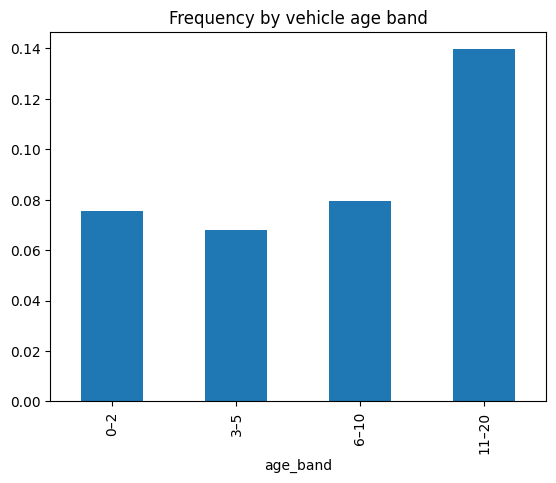

In [6]:
# Bin vehicle age into actuarial bands
bins   = [-0.5, 2, 5, 10, 20]
labels = ["0–2", "3–5", "6–10", "11–20"]
motor["age_band"] = pd.cut(
    motor["vehicle_age_years"],
    bins=bins, labels=labels,
)

# Exposure-weighted frequency by band
freq = (motor.groupby("age_band", observed=True)
          .apply(lambda g:
              g["claim_count"].sum()
              / g["exposure_years"].sum()))

freq.plot(kind="bar",
          title="Frequency by vehicle age band")

Quick sanity-check: compare to the slide's printed values (~6%, 7.5%, 9.4%, 12.1%). The numbers won't be identical — Colab's matplotlib auto-formats — but the monotonic shape should be unmistakable.

In [7]:
# Print the frequency table for the record
print("Exposure-weighted frequency by vehicle age band:")
print(freq.apply(lambda x: f"{x:.1%}"))

Exposure-weighted frequency by vehicle age band:
age_band
0–2       7.5%
3–5       6.8%
6–10      7.9%
11–20    13.9%
dtype: str


## 3. ABC Health 2024 — quick look — slide S1.P2.13

Same three-box mental model as motor (policy + exposure + claim), at member-level grain. Below: load, peek at shape, confirm the schema matches what the slide diagram showed.

In [8]:
try:
    health = pd.read_csv(
        HEALTH_URL,
        parse_dates=["inception_date"],
    )
    print(f"Loaded ABC Health 2024 from {HEALTH_URL}")
except Exception:
    print("URL not yet replaced — using inline-generated ABC Health 2024 (seed=43)")
    health = _generate_health()

print(f"Policies: {health['policy_id'].nunique():,}")
print(f"Members:  {len(health):,}")
health.head()

Loaded ABC Health 2024 from https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_health_2024.csv
Policies: 3,200
Members:  7,678


,policy_id,member_id,relationship,inception_date,exposure_years,member_age,member_gender,sum_insured_inr,product_tier,region,pre_existing_flag,hospitalisation_count,claim_amount_inr,daycare_count
0,ABC-HLT-000001,ABC-HLT-000001-01,Self,2024-04-28,0.68,55,F,1500000,Bronze,Tier2,1,0,0.00,0
1,ABC-HLT-000002,ABC-HLT-000002-01,Self,2024-01-28,0.93,30,M,500000,Silver,Tier3,0,0,0.00,0
2,ABC-HLT-000002,ABC-HLT-000002-02,Spouse,2024-01-28,0.93,28,F,500000,Silver,Tier3,0,0,0.00,0
3,ABC-HLT-000003,ABC-HLT-000003-01,Self,2024-01-08,0.98,29,F,500000,Bronze,Tier2,0,0,0.00,0
4,ABC-HLT-000004,ABC-HLT-000004-01,Self,2024-01-26,0.93,44,M,750000,Bronze,Tier1,0,0,0.00,0


In [9]:
# Hospitalisation frequency, exposure-weighted, by product tier
health_freq = (health.groupby("product_tier")
                  .apply(lambda g:
                      g["hospitalisation_count"].sum()
                      / g["exposure_years"].sum()))
print("Hospitalisation frequency by product tier:")
print(health_freq.apply(lambda x: f"{x:.2%}"))

Hospitalisation frequency by product tier:
product_tier
Bronze    4.56%
Gold      3.25%
Silver    4.10%
dtype: str


## 4. ABC Life — quick look — slide S1.P2.14

Issue-cohort grain, with two distinct target columns: `lapse_flag` and `claim_flag`. Vikram, ABC Life's valuation actuary, models them with separate models — the drivers of someone surrendering are not the drivers of someone dying.

In [10]:
try:
    life = pd.read_csv(
        LIFE_URL,
        parse_dates=["issue_date"],
    )
    print(f"Loaded ABC Life Term Cohort from {LIFE_URL}")
except Exception:
    print("URL not yet replaced — using inline-generated ABC Life Term Cohort (seed=44)")
    life = _generate_life()

print(f"Policies: {len(life):,}")
life.head()

Loaded ABC Life Term Cohort from https://raw.githubusercontent.com/rohanyashraj/ifoa-workshop/main/data/abc_life_term_cohort.csv
Policies: 50,000


,policy_id,issue_date,issue_age,gender,sum_assured_inr,policy_term_years,premium_frequency,annualised_premium_inr,smoker_status,bmi,medical_uw_route,region,lapse_flag,lapse_duration_months,claim_flag
0,ABC-LIF-0000001,2015-07-09,41,M,9300000,5,Annual,"7,645.00",S,27.90,FullMed,Tier3,0,-1,0
1,ABC-LIF-0000002,2016-03-18,43,F,2000000,40,Annual,"5,000.00",NS,33.70,TeleMed,Tier2,1,10,0
2,ABC-LIF-0000003,2021-07-12,42,F,2200000,30,Monthly,"5,000.00",NS,26.60,FullMed,Tier3,0,-1,0
3,ABC-LIF-0000004,2022-10-01,31,F,4600000,10,Monthly,"5,000.00",NS,21.70,TeleMed,Tier1,0,-1,0
4,ABC-LIF-0000005,2021-12-30,29,M,2800000,20,Monthly,"5,000.00",NS,28.30,TeleMed,Tier2,0,-1,0


In [11]:
# 13-month persistency — proxy by lapses occurring within the first 13 months
issued_long_enough = life[
    (pd.Timestamp("2024-12-31") - life["issue_date"]).dt.days >= 13 * 30
].copy()
lapsed_within_13m = (
    (issued_long_enough["lapse_flag"] == 1)
    & (issued_long_enough["lapse_duration_months"].between(1, 13))
)
persistency_13m = 1 - lapsed_within_13m.mean()
print(f"13-month persistency (sample): {persistency_13m:.1%}")

13-month persistency (sample): 84.2%


In [12]:
# The stylised mortality function from the slide: q_x = 0.001 * 2^((x-30)/10)
def q_x(age: int) -> float:
    return 0.001 * 2 ** ((age - 30) / 10)

ages = [25, 30, 35, 40, 50, 60, 70]
print("Stylised q_x table:")
for a in ages:
    print(f"  q_{a:>2d} = {q_x(a):.5f}")

Stylised q_x table:
  q_25 = 0.00071
  q_30 = 0.00100
  q_35 = 0.00141
  q_40 = 0.00200
  q_50 = 0.00400
  q_60 = 0.00800
  q_70 = 0.01600


## 5. Three-minute exercise — find the leakage column — slide S1.P2.15

We're going to predict whether a policy claimed at all — a binary target. The cell below fits a logistic regression on every numeric column it can find. The test AUC comes back at 1.00.

That's not skill — it's leakage. One column gives the answer away. **Find it, don't run the next cell yet.**

Hint: it's measured in rupees.

In [13]:
# Build the binary target and a "reasonable-looking" feature matrix.
# We drop the obvious post-event columns (claim_count, fraud_flag) — the kind of
# clean-up an actuary would do without thinking. One leak still slips through.
motor = motor.copy()
motor["did_claim"] = (motor["claim_count"] > 0).astype(int)

obvious_targets = {"did_claim", "claim_count", "fraud_flag"}
num_cols = [c for c in motor.select_dtypes(include="number").columns
            if c not in obvious_targets]
X = motor[num_cols]
y = motor["did_claim"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y,
)

clf = LogisticRegression(max_iter=2_000)
clf.fit(X_train, y_train)
auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(f"Test AUC: {auc:.3f}   ← if this is ~1.00, we have a leak")
print(f"Features used: {num_cols}")

Test AUC: 1.000   ← if this is ~1.00, we have a leak
Features used: ['exposure_years', 'vehicle_age_years', 'cubic_capacity', 'idv_inr', 'ncb_pct', 'policyholder_age', 'prior_claims_3y', 'claim_amount_inr']


Three minutes on the clock. When you have a candidate, expand the box below.

<details>
<summary><b>👉 Click to reveal the answer</b></summary>

The leakage column is **`claim_amount_inr`**.

`claim_amount_inr` is non-zero **if and only if** `claim_count > 0`. Since our target `did_claim` is just `claim_count > 0` cast to an integer, the rupee amount perfectly predicts the target — AUC of 1.0 is mathematical certainty, not modelling skill. Including it means the model "learns" that a policy claimed by checking whether the dataset already says it claimed.

The next cell shows the diagnosis (perfect rank correlation between `claim_amount_inr` and the target), then refits the same logistic regression with that column removed — and you'll see AUC drop to a realistic, non-perfect number.

**General rule (from slide S1.P2.12):** if a feature is knowable only **after** the event you're predicting, it's leakage. Drop it.

</details>

In [14]:
# Diagnosis — which column has near-perfect rank correlation with the target?
diag = X_train.assign(did_claim=y_train).corr()["did_claim"].abs().sort_values(ascending=False)
print("Absolute correlation of each feature with did_claim:")
print(diag.drop("did_claim"))
print()
print("→ claim_amount_inr is the leakage column.")

Absolute correlation of each feature with did_claim:
claim_amount_inr    0.80
prior_claims_3y     0.10
exposure_years      0.10
ncb_pct             0.06
vehicle_age_years   0.05
cubic_capacity      0.03
policyholder_age    0.01
idv_inr             0.01
Name: did_claim, dtype: float64

→ claim_amount_inr is the leakage column.


In [15]:
# Refit without the leakage column — this is the honest baseline
honest_features = [c for c in num_cols if c != "claim_amount_inr"]
X2 = motor[honest_features]
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.30, random_state=SEED, stratify=y,
)
clf2 = LogisticRegression(max_iter=2_000)
clf2.fit(X_train2, y_train2)
auc2 = roc_auc_score(y_test2, clf2.predict_proba(X_test2)[:, 1])
print(f"Honest test AUC (no claim_amount_inr): {auc2:.3f}")
print(f"This is what an actuary lives with — a realistic baseline to beat in Part 3.")

Honest test AUC (no claim_amount_inr): 0.649
This is what an actuary lives with — a realistic baseline to beat in Part 3.


## Wrap-up

You should now be able to:
- Load any of the three ABC Insurer datasets and run the standard inspection drill (`head`, `info`, `describe`).
- Compute exposure-weighted rates the way an actuary actually computes them — sum claims, sum exposure, divide.
- Recognise the three-box mental model (policy + exposure + claim) across motor, health, and life schemas.
- Spot target leakage by checking absolute correlation against the target before you trust an AUC of 1.00.

**Where to next:** open `02_predictive_modeling.ipynb` for the GLM, Random Forest, and XGBoost on this same ABC Motor 2024 book.

**Companion slides:** S1.P2.10 – S1.P2.15 of the Session 1 deck.

**Questions?** Bring them to the live Q&A or post in the workshop Slack channel.

In [16]:
print("01_data_foundations.ipynb — demonstrated load + inspect, exposure-weighted "
      "frequency by vehicle age, Health and Life quick looks, and target-leakage diagnosis.")

01_data_foundations.ipynb — demonstrated load + inspect, exposure-weighted frequency by vehicle age, Health and Life quick looks, and target-leakage diagnosis.
